In [3]:
from google.colab import drive
drive.mount("/content/drive")



Mounted at /content/drive


In [4]:
import os
os.chdir("/content")
print(os.getcwd())


/content


In [5]:
!rm -rf /content/Task-driven-low-light-enhancement
!git clone https://github.com/SarthakBaghel/Task-driven-low-light-enhancement.git /content/Task-driven-low-light-enhancement
%cd /content/Task-driven-low-light-enhancement
!pip install -r requirements.txt


Cloning into '/content/Task-driven-low-light-enhancement'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 72 (delta 15), reused 67 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 158.34 KiB | 5.65 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/Task-driven-low-light-enhancement
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 116.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [6]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


In [7]:
from pathlib import Path
import os
import shutil

DRIVE_ROOT = Path("/content/drive/MyDrive")
PIPELINE_ROOT = DRIVE_ROOT / "task_driven_video_pipeline"
KAGGLE_V1_ROOT = PIPELINE_ROOT / "kaggle_v1"
CHECKPOINTS_ROOT = DRIVE_ROOT / "task_driven_checkpoints" / "kaggle_v1"

RUN_TAG = "subject_class_balanced_20k"

TRAIN_LOWLIGHT_ROOT = KAGGLE_V1_ROOT / f"train_lowlight_{RUN_TAG}_eye_mid"
VAL_LOWLIGHT_ROOT = KAGGLE_V1_ROOT / f"val_lowlight_{RUN_TAG}_eye_mid"
TEST_LOWLIGHT_ROOT = KAGGLE_V1_ROOT / f"test_lowlight_{RUN_TAG}_eye_mid"

ENHANCER_BUNDLE_ROOT = Path(f"/content/kaggle_v1_enhancer_bundle_{RUN_TAG}_eye_mid")
ENHANCER_TRAIN_LINK = ENHANCER_BUNDLE_ROOT / "train"
ENHANCER_VAL_LINK = ENHANCER_BUNDLE_ROOT / "val"

ENHANCER_CKPT_DIR = CHECKPOINTS_ROOT / f"enhancer_{RUN_TAG}_eye_mid"
ENHANCER_HISTORY_PATH = ENHANCER_CKPT_DIR / "enhancer_training_history.json"
ENHANCER_BEST_CKPT = ENHANCER_CKPT_DIR / "enhancer_best.pt"
ENHANCER_LAST_CKPT = ENHANCER_CKPT_DIR / "enhancer_last.pt"

ENHANCER_PREVIEW_DIR = KAGGLE_V1_ROOT / f"enhancer_preview_{RUN_TAG}_eye_mid"

assert TRAIN_LOWLIGHT_ROOT.exists(), f"Missing: {TRAIN_LOWLIGHT_ROOT}"
assert VAL_LOWLIGHT_ROOT.exists(), f"Missing: {VAL_LOWLIGHT_ROOT}"

ENHANCER_PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("TRAIN_LOWLIGHT_ROOT:", TRAIN_LOWLIGHT_ROOT)
print("VAL_LOWLIGHT_ROOT:", VAL_LOWLIGHT_ROOT)
print("ENHANCER_BUNDLE_ROOT:", ENHANCER_BUNDLE_ROOT)
print("ENHANCER_CKPT_DIR:", ENHANCER_CKPT_DIR)


TRAIN_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_lowlight_subject_class_balanced_20k_eye_mid
VAL_LOWLIGHT_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid
ENHANCER_BUNDLE_ROOT: /content/kaggle_v1_enhancer_bundle_subject_class_balanced_20k_eye_mid
ENHANCER_CKPT_DIR: /content/drive/MyDrive/task_driven_checkpoints/kaggle_v1/enhancer_subject_class_balanced_20k_eye_mid


In [8]:
!find "{TRAIN_LOWLIGHT_ROOT}/open" -type f | wc -l
!find "{TRAIN_LOWLIGHT_ROOT}/closed" -type f | wc -l

!find "{VAL_LOWLIGHT_ROOT}/open" -type f | wc -l
!find "{VAL_LOWLIGHT_ROOT}/closed" -type f | wc -l


72
86
find: ‘/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid/open’: No such file or directory
0
472


In [9]:
if ENHANCER_BUNDLE_ROOT.exists():
    shutil.rmtree(ENHANCER_BUNDLE_ROOT)

ENHANCER_BUNDLE_ROOT.mkdir(parents=True, exist_ok=True)

os.symlink(TRAIN_LOWLIGHT_ROOT, ENHANCER_TRAIN_LINK)
os.symlink(VAL_LOWLIGHT_ROOT, ENHANCER_VAL_LINK)

print("Created enhancer bundle:", ENHANCER_BUNDLE_ROOT)
print("train ->", ENHANCER_TRAIN_LINK.resolve())
print("val   ->", ENHANCER_VAL_LINK.resolve())


Created enhancer bundle: /content/kaggle_v1_enhancer_bundle_subject_class_balanced_20k_eye_mid
train -> /content/drive/.shortcut-targets-by-id/1PGJCrZrodZvhgcqSmVi73Qs7wZAAByFc/task_driven_video_pipeline/kaggle_v1/train_lowlight_subject_class_balanced_20k_eye_mid
val   -> /content/drive/.shortcut-targets-by-id/1PGJCrZrodZvhgcqSmVi73Qs7wZAAByFc/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid


In [10]:
!find "{ENHANCER_BUNDLE_ROOT}" -maxdepth 2 -type d | sed -n '1,40p'


/content/kaggle_v1_enhancer_bundle_subject_class_balanced_20k_eye_mid


In [11]:
!python3 /content/Task-driven-low-light-enhancement/train_enhancer.py \
  {ENHANCER_BUNDLE_ROOT} \
  --device auto \
  --epochs 15 \
  --batch-size 16 \
  --learning-rate 1e-4 \
  --weight-decay 1e-4 \
  --image-size 224 \
  --num-workers 2 \
  --seed 42 \
  --scheduler-factor 0.5 \
  --scheduler-patience 2 \
  --early-stopping-patience 5 \
  --min-delta 1e-4 \
  --gradient-clip-norm 1.0 \
  --checkpoint-dir {ENHANCER_CKPT_DIR} \
  --history-path {ENHANCER_HISTORY_PATH} \
  --save-every-epoch


Training device: cuda
Loaded classes (ignored for enhancer losses): {'open': 0, 'closed': 1}
Train images: 158
Val images: 472
Epoch 01/15 | lr=0.000100 | time=44.7s
Train loss=2.0886 | exp=0.2086 | color=0.0001 | smooth=0.0000 | spatial=0.0000
Val   loss=1.6346 | exp=0.1630 | color=0.0003 | smooth=0.0000 | spatial=0.0000
Best checkpoint updated: epoch=1 val_loss=1.6346
Epoch 02/15 | lr=0.000100 | time=5.5s
Train loss=1.8392 | exp=0.1835 | color=0.0001 | smooth=0.0000 | spatial=0.0000
Val   loss=1.3255 | exp=0.1320 | color=0.0003 | smooth=0.0000 | spatial=0.0001
Best checkpoint updated: epoch=2 val_loss=1.3255
Epoch 03/15 | lr=0.000100 | time=5.0s
Train loss=1.4810 | exp=0.1474 | color=0.0003 | smooth=0.0000 | spatial=0.0001
Val   loss=0.8872 | exp=0.0877 | color=0.0004 | smooth=0.0000 | spatial=0.0004
Best checkpoint updated: epoch=3 val_loss=0.8872
Epoch 04/15 | lr=0.000100 | time=4.1s
Train loss=0.9119 | exp=0.0897 | color=0.0007 | smooth=0.0001 | spatial=0.0005
Val   loss=0.3420 | 

In [12]:
!ls "{ENHANCER_CKPT_DIR}"
!ls "{ENHANCER_BEST_CKPT}"
!ls "{ENHANCER_LAST_CKPT}"
!ls "{ENHANCER_HISTORY_PATH}"


enhancer_best.pt       enhancer_epoch_006.pt  enhancer_epoch_012.pt
enhancer_epoch_001.pt  enhancer_epoch_007.pt  enhancer_epoch_013.pt
enhancer_epoch_002.pt  enhancer_epoch_008.pt  enhancer_epoch_014.pt
enhancer_epoch_003.pt  enhancer_epoch_009.pt  enhancer_epoch_015.pt
enhancer_epoch_004.pt  enhancer_epoch_010.pt  enhancer_last.pt
enhancer_epoch_005.pt  enhancer_epoch_011.pt  enhancer_training_history.json
/content/drive/MyDrive/task_driven_checkpoints/kaggle_v1/enhancer_subject_class_balanced_20k_eye_mid/enhancer_best.pt
/content/drive/MyDrive/task_driven_checkpoints/kaggle_v1/enhancer_subject_class_balanced_20k_eye_mid/enhancer_last.pt
/content/drive/MyDrive/task_driven_checkpoints/kaggle_v1/enhancer_subject_class_balanced_20k_eye_mid/enhancer_training_history.json


In [13]:
import json
from pathlib import Path

history = json.loads(Path(ENHANCER_HISTORY_PATH).read_text())
print("Epochs recorded:", len(history))
print("Last epoch entry:")
print(json.dumps(history[-1], indent=2)[:3000])


Epochs recorded: 15
Last epoch entry:
{
  "epoch": 15,
  "learning_rate": 0.0001,
  "epoch_seconds": 4.182796079999889,
  "train": {
    "loss": 0.024866184033453465,
    "exposure": 0.0001329710277786944,
    "color_constancy": 5.4816748615849065e-05,
    "illumination_smoothness": 0.00010132386596524156,
    "spatial_consistency": 0.002997616888023913
  },
  "val": {
    "loss": 0.021339794745047887,
    "exposure": 0.00018936777535903578,
    "color_constancy": 0.000265123006564257,
    "illumination_smoothness": 7.69668486706602e-05,
    "spatial_consistency": 0.0027271324458221593
  }
}


In [14]:
from pathlib import Path

val_open_samples = sorted((VAL_LOWLIGHT_ROOT / "open").glob("*"))
val_closed_samples = sorted((VAL_LOWLIGHT_ROOT / "closed").glob("*"))

sample_image = val_open_samples[0] if val_open_samples else val_closed_samples[0]

comparison_path = ENHANCER_PREVIEW_DIR / "sample_comparison.png"
enhanced_path = ENHANCER_PREVIEW_DIR / "sample_enhanced.png"

print("Sample image:", sample_image)
print("Comparison path:", comparison_path)
print("Enhanced path:", enhanced_path)


Sample image: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid/open/s0011_01509_0_0_1_0_0_01.png
Comparison path: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/enhancer_preview_subject_class_balanced_20k_eye_mid/sample_comparison.png
Enhanced path: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/enhancer_preview_subject_class_balanced_20k_eye_mid/sample_enhanced.png


In [15]:
!python3 /content/Task-driven-low-light-enhancement/visualize_enhancement.py \
  {sample_image} \
  --checkpoint {ENHANCER_BEST_CKPT} \
  --device auto \
  --output-path {comparison_path} \
  --enhanced-output-path {enhanced_path}


Input image: /content/drive/.shortcut-targets-by-id/1PGJCrZrodZvhgcqSmVi73Qs7wZAAByFc/task_driven_video_pipeline/kaggle_v1/val_lowlight_subject_class_balanced_20k_eye_mid/open/s0011_01509_0_0_1_0_0_01.png
Enhanced image: /content/drive/.shortcut-targets-by-id/1PGJCrZrodZvhgcqSmVi73Qs7wZAAByFc/task_driven_video_pipeline/kaggle_v1/enhancer_preview_subject_class_balanced_20k_eye_mid/sample_enhanced.png
Comparison figure: /content/drive/.shortcut-targets-by-id/1PGJCrZrodZvhgcqSmVi73Qs7wZAAByFc/task_driven_video_pipeline/kaggle_v1/enhancer_preview_subject_class_balanced_20k_eye_mid/sample_comparison.png
Curve map tensor shape: (1, 8, 3, 95, 95)


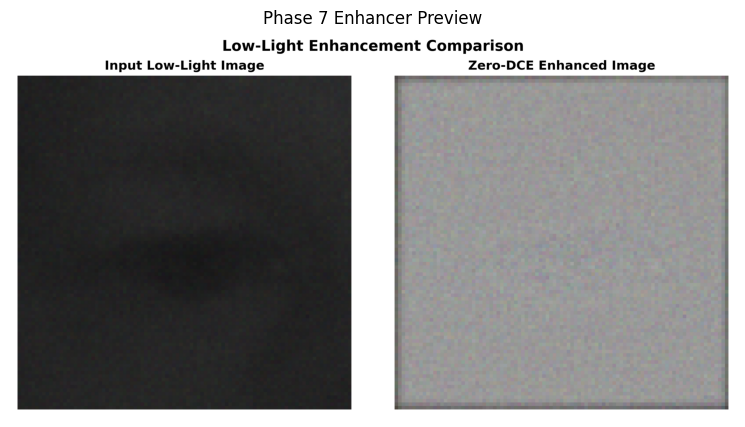

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(comparison_path)

plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Phase 7 Enhancer Preview")
plt.show()


In [17]:
print("Phase 7 complete.")
print("ENHANCER_BEST_CKPT:", ENHANCER_BEST_CKPT)
print("ENHANCER_LAST_CKPT:", ENHANCER_LAST_CKPT)
print("ENHANCER_HISTORY_PATH:", ENHANCER_HISTORY_PATH)
print("ENHANCER_PREVIEW_DIR:", ENHANCER_PREVIEW_DIR)


Phase 7 complete.
ENHANCER_BEST_CKPT: /content/drive/MyDrive/task_driven_checkpoints/kaggle_v1/enhancer_subject_class_balanced_20k_eye_mid/enhancer_best.pt
ENHANCER_LAST_CKPT: /content/drive/MyDrive/task_driven_checkpoints/kaggle_v1/enhancer_subject_class_balanced_20k_eye_mid/enhancer_last.pt
ENHANCER_HISTORY_PATH: /content/drive/MyDrive/task_driven_checkpoints/kaggle_v1/enhancer_subject_class_balanced_20k_eye_mid/enhancer_training_history.json
ENHANCER_PREVIEW_DIR: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/enhancer_preview_subject_class_balanced_20k_eye_mid
